In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import norm

from metrics.old_model import OldModel as OM

In [2]:
t = 3
horizon = 3
model_name = 'iTransformer'

### Load pred values

In [3]:
merged = pd.read_csv(f'../data/merged_{model_name}_20k_all.csv')
merged = merged[t::horizon]

Y = merged["y"]
pred_l = merged['05']
pred_h = merged['95']
w_pred = pred_h - pred_l

## Success Rate

A Success Rate a konfidencia kritériumot ellenőrzi, azaz, hogy a jövőbeli érték 90%-os valószínűséggel az intervallumokba essen.
Nyílván, ha nagyobb a százalék, az előnyösebb.
Itt kiszámítjuk ezt a valószínűséget:

In [4]:
# A jövőbeli Y érték, az alsó (l) és a felső (h) percentilis között van
hit = np.logical_and(Y >= pred_l, Y <= pred_h)

# A numpy-ban bool arrray átlaga a True értékek gyakorisága, azaz pont a valószínűség
sr = np.mean(hit)
sr

0.8941398865784499

## Interval Ratio

Az Interval Ratio a prediktált intervallumok szélességét viszonyítja a referencia prediktor ugyanazon bemenetével kapott intervallum szélességhez
Itt a minél kissebb érték az előnyösebb.
Az SR-el ellentétben ezt minden egyes adatpontra ki lehet számítani, eloszlást is ki lehet vele rajzoltatni.
Amikor az IR-ről skalár formájában beszélünk, akkor a sokaság átlagát értjük alatta:

In [5]:
# sztochasztikus modell betoltese
ref_model = OM(f'../data/stochastic_{t}hr.csv')

l, h = ref_model.predict(Y)

w1 = h - l


In [6]:
ir = w_pred / w1
mir = np.mean(ir)
mir

2.392008190315682

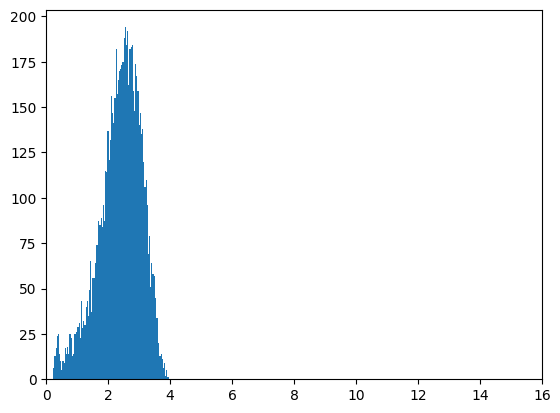

In [7]:
fig, ax = plt.subplots()
ax.hist(ir, bins=100)
ax.set_xlim([0, 16]);


## I-Score
Az I-Score az egymás kárára javuló metrikákat értékeli.
A nagyobb érték a jobb.

In [8]:
iscore = norm.ppf(0.5 + sr / 2.0) / norm.ppf(0.95) / mir
iscore

0.4110008372275364